# 🛡️ AI Analytics Platform for Road Safety & Insurance Risk
**Project:** Accident Severity Prediction System  
**Developed by:** Giulia Bugatti | **Award:** 3rd Place - Sompo Seguros Innovation Challenge

### 1. Executive Summary
This notebook develops a predictive pipeline to classify traffic accident severity using historical data. By identifying high-risk patterns, we provide a tool for:
* **Risk Scoring:** Assisting insurance companies in premium calculation.
* **Emergency Response:** Prioritizing resources for potentially fatal incidents.
* **Public Policy:** Identifying the "Lethality Risk Index" across federal highways.

#### Analytical Roadmap
1. **Exploratory Data Analysis (EDA):** Understanding class imbalance and feature distributions.
2. **Data Cleaning:** Handling domain-specific anomalies (Age/Vehicle Year).
3. **Advanced Feature Engineering:** Creating high-impact interaction variables.
4. **Resampling & Modeling:** Solving class imbalance with SMOTE and training XGBoost.

### 2. Technical Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from collections import Counter
from scipy.stats.mstats import winsorize

# Machine Learning & Optimization
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import shap
import os

# Environment Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid", palette="muted")

print("✅ Professional Environment Ready.")

✅ Professional Environment Ready.


c:\Users\gfbugatti\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3. Data Mining & Detailed Inspection

In [2]:
# Direct link to the Raw data on GitHub for total portability
DATA_URL = "https://raw.githubusercontent.com/giuliabugatti09/AI-Analytics-Platform-for-Insurance/main/data/acidentes2025_todas_causas_tipos.csv"

try:
    df = pd.read_csv(DATA_URL, encoding='utf-8', sep=',')
    print(f"✅ Success! Dataset loaded. Shape: {df.shape}")
except Exception as e:
    print(f"❌ Error loading data: {e}")

display(df.head())

✅ Success! Dataset loaded. Shape: (182434, 37)


,id,pesid,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_principal,causa_acidente,ordem_tipo_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,id_veiculo,tipo_veiculo,marca,ano_fabricacao_veiculo,tipo_envolvido,estado_fisico,idade,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude,regional,delegacia,uop
0,652468,1467636.0,2025-01-01,quarta-feira,0:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,Reação tardia ou ineficiente do condutor,1,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Não,1172939.0,Automóvel,VW/GOL 1.0L MC4,2018.0,Condutor,Não Informado,NaN,Não Informado,0.0,0.0,0.0,0.0,"-820,760,697","-3,498,372,005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE
1,652468,1467635.0,2025-01-01,quarta-feira,0:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,Reação tardia ou ineficiente do condutor,1,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Não,1172938.0,Motocicleta,HONDA/NXR150 BROS ES,2009.0,Passageiro,Lesões Leves,28.0,Feminino,0.0,1.0,0.0,0.0,"-820,760,697","-3,498,372,005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE
2,652468,1467634.0,2025-01-01,quarta-feira,0:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,Reação tardia ou ineficiente do condutor,1,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Não,1172938.0,Motocicleta,HONDA/NXR150 BROS ES,2009.0,Condutor,Lesões Leves,29.0,Masculino,0.0,1.0,0.0,0.0,"-820,760,697","-3,498,372,005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE
3,652468,1467637.0,2025-01-01,quarta-feira,0:30:00,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,Reação tardia ou ineficiente do condutor,1,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Não,NaN,NaN,NA/NA,NaN,Testemunha,Não Informado,NaN,Não Informado,0.0,0.0,0.0,0.0,"-820,760,697","-3,498,372,005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE
4,652469,1467628.0,2025-01-01,quarta-feira,0:50:00,SC,101.0,120,ITAJAI,Sim,Ausência de reação do condutor,1,Tombamento,Com Vítimas Feridas,Plena Noite,Decrescente,Nublado,Dupla,Reta,Não,1172934.0,Motocicleta,HONDA/CG 160 TITAN EX,2016.0,Passageiro,Lesões Leves,24.0,Feminino,0.0,1.0,0.0,0.0,"-26,912,758","-48,711,998",SPRF-SC,DEL04-SC,UOP04-DEL04-SC


In [3]:
print("=== GLOBAL INFORMATION ===")

print(f"5 first rows:\n{df.head()}")
print(f"Columns: {df.columns.tolist()}")
print(f"Data Types:\n{df.dtypes}")
print(f"Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
display(df.info())

print("\n=== INITIAL DESCRIPTIVE STATISTICS ===")
display(df.describe())
display(df.describe(include=['object']))

=== GLOBAL INFORMATION ===
5 first rows:
       id      pesid data_inversa    dia_semana  horario  uf     br    km  \
0  652468  1467636.0   2025-01-01  quarta-feira  0:30:00  PE  101.0  89,5   
1  652468  1467635.0   2025-01-01  quarta-feira  0:30:00  PE  101.0  89,5   
2  652468  1467634.0   2025-01-01  quarta-feira  0:30:00  PE  101.0  89,5   
3  652468  1467637.0   2025-01-01  quarta-feira  0:30:00  PE  101.0  89,5   
4  652469  1467628.0   2025-01-01  quarta-feira  0:50:00  SC  101.0   120   

                 municipio causa_principal  \
0  JABOATAO DOS GUARARAPES             Sim   
1  JABOATAO DOS GUARARAPES             Sim   
2  JABOATAO DOS GUARARAPES             Sim   
3  JABOATAO DOS GUARARAPES             Sim   
4                   ITAJAI             Sim   

                             causa_acidente  ordem_tipo_acidente  \
0  Reação tardia ou ineficiente do condutor                    1   
1  Reação tardia ou ineficiente do condutor                    1   
2  Reação tardi

None


=== INITIAL DESCRIPTIVE STATISTICS ===


,id,pesid,br,ordem_tipo_acidente,id_veiculo,ano_fabricacao_veiculo,idade,ilesos,feridos_leves,feridos_graves,mortos
count,182434.000000,1.650240e+05,181907.000000,182434.000000,1.766460e+05,176646.000000,149598.000000,165024.000000,165024.000000,165024.000000,165024.000000
mean,666671.609514,1.500061e+06,219.022836,1.750326,1.197055e+06,1910.443022,39.846114,0.415903,0.341587,0.123212,0.050356
std,10252.625035,1.835830e+04,126.164930,1.018627,1.420517e+04,444.639520,37.961193,0.492878,0.474243,0.328682,0.218680
min,652468.000000,1.467627e+06,10.000000,1.000000,1.172934e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,658532.000000,1.484132e+06,116.000000,1.000000,1.184510e+06,2008.000000,28.000000,0.000000,0.000000,0.000000,0.000000
50%,665197.000000,1.500740e+06,174.000000,1.000000,1.197293e+06,2014.000000,38.000000,0.000000,0.000000,0.000000,0.000000
75%,671547.000000,1.516227e+06,343.000000,2.000000,1.209688e+06,2021.000000,50.000000,1.000000,1.000000,0.000000,0.000000
max,691875.000000,1.538257e+06,495.000000,14.000000,1.227060e+06,2025.000000,2024.000000,1.000000,1.000000,1.000000,1.000000


,data_inversa,dia_semana,horario,uf,km,municipio,causa_principal,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,tipo_veiculo,marca,tipo_envolvido,estado_fisico,sexo,latitude,longitude,regional,delegacia,uop
count,182434,182434,182434,182434,181907,182434,182434,182434,182434,182431,182434,182434,182434,182434,182434,182434,176646,182434,165024,165024,165024,182434,182434,182434,182355,182193
unique,120,7,1181,27,5207,1606,2,70,17,3,4,3,8,3,367,2,23,4953,5,5,4,20307,20299,28,153,393
top,2025-04-21,sábado,17:00:00,MG,580,CURITIBA,Sim,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,Automóvel,Não Informado/Não Informado,Condutor,Ileso,Masculino,"-1,035,204,598","-4,516,752,282",SPRF-MG,DEL01-PR,UOP01-DEL01-PB
freq,2647,28907,2404,25518,860,2858,106960,26417,26544,136378,104340,99574,106808,98788,94510,111198,60759,7178,109850,68634,114048,792,792,25470,8669,2831


### 4. Target Variable Analysis

📈 CLASS DISTRIBUTION REPORT


,Count,Percentage (%)
classificacao_acidente,,
Com Vítimas Feridas,136378,74.76
Com Vítimas Fatais,29106,15.95
Sem Vítimas,16947,9.29


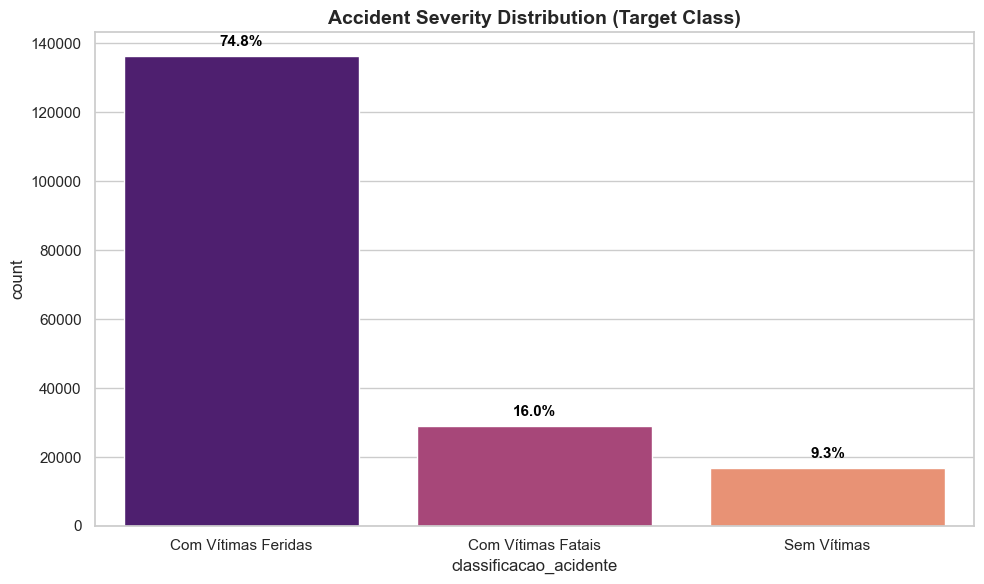

⚠️ Observation: The fatal class represents only 9.29% of the data, requiring SMOTE later.


In [4]:
# --- TARGET ANALYSIS: Accident Severity ---
target = 'classificacao_acidente'

# Calculating frequency and percentage
counts = df[target].value_counts()
percents = df[target].value_counts(normalize=True) * 100

# Summary Table
target_report = pd.DataFrame({'Count': counts, 'Percentage (%)': percents.round(2)})
print("📈 CLASS DISTRIBUTION REPORT")
display(target_report)

# Professional Visualization
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x=target, palette='magma', order=counts.index)
plt.title('Accident Severity Distribution (Target Class)', fontsize=14, fontweight='bold')

# Adding percentages on top of bars
for i, p in enumerate(ax.patches):
    ax.annotate(f'{percents.iloc[i]:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"⚠️ Observation: The fatal class represents only {percents.min():.2f}% of the data, requiring SMOTE later.")

### 5. Statistical Visualization (Histograms & Outliers)

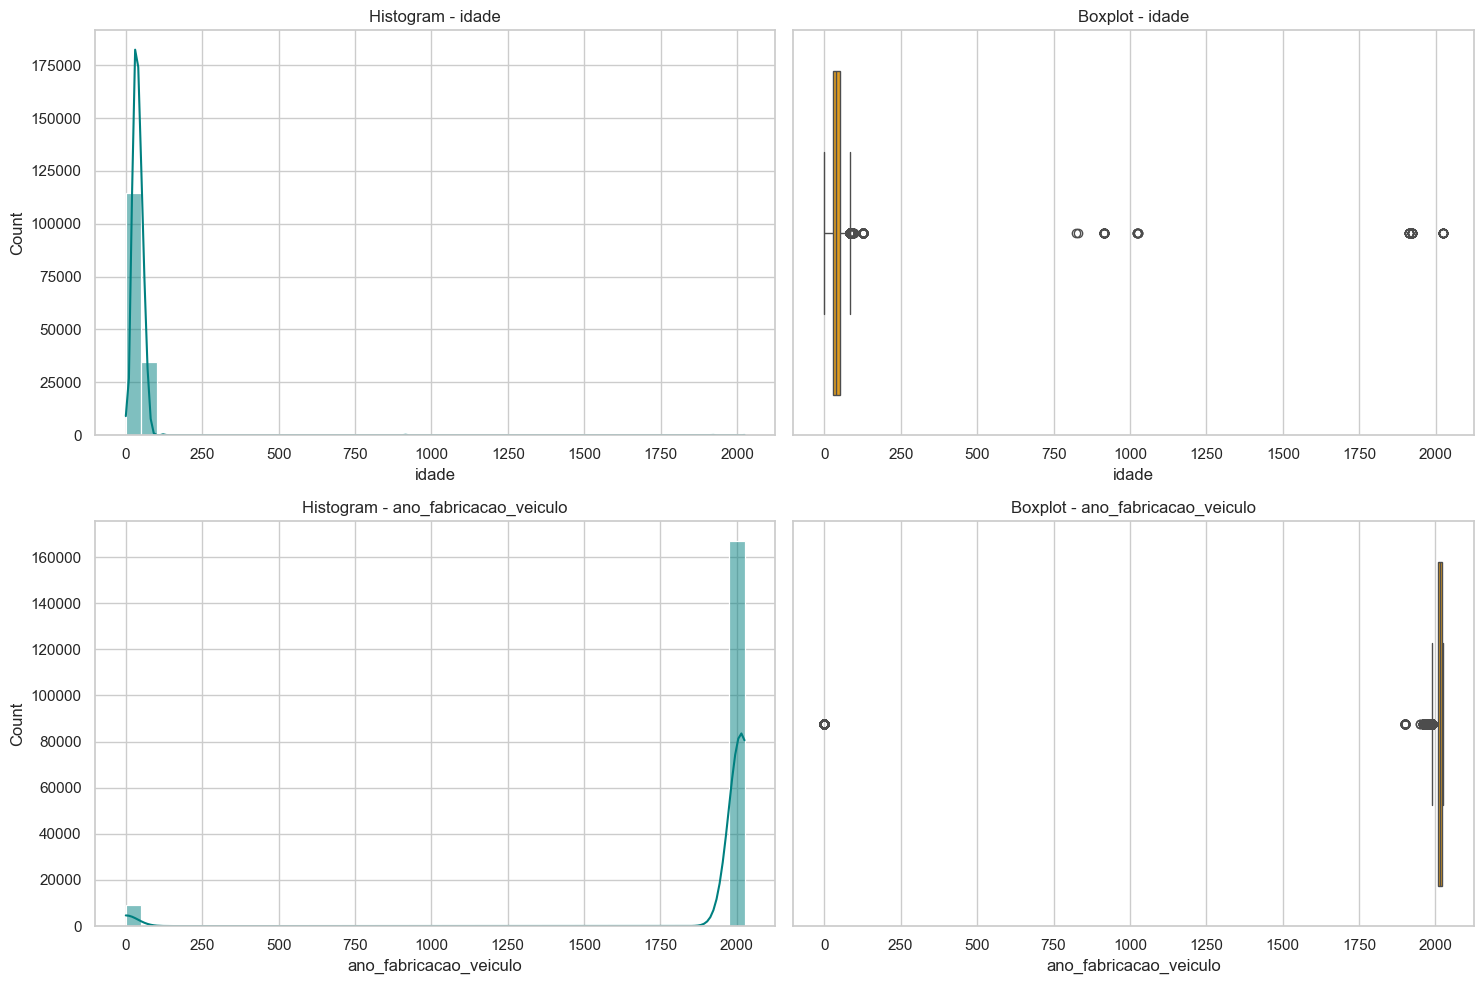

🔍 INSIGHT: Drivers over 110 years old and vehicle years near 0 detected as input errors.


In [5]:
# Analyzing key numerical features for anomalies
analysis_cols = ['idade', 'ano_fabricacao_veiculo']

fig, axes = plt.subplots(len(analysis_cols), 2, figsize=(15, 5 * len(analysis_cols)))

for i, col in enumerate(analysis_cols):
    # Histogram
    sns.histplot(df[col].dropna(), bins=40, kde=True, ax=axes[i, 0], color='teal')
    axes[i, 0].set_title(f'Histogram - {col}')

    # Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color='orange')
    axes[i, 1].set_title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

# Quick Insight Markdown (English)
print("🔍 INSIGHT: Drivers over 110 years old and vehicle years near 0 detected as input errors.")

### 6. Data Cleaning & Winsorization

In [6]:
# --- DATA CLEANING: Anomaly Suppression ---
df_clean = df.copy()

# 1. Extreme Outlier Filtering (Drivers > 110 years or <= 0)
df_clean.loc[(df_clean['idade'] > 110) | (df_clean['idade'] <= 0), 'idade'] = np.nan
df_clean['idade'] = df_clean['idade'].fillna(df_clean['idade'].median())

# 2. Vehicle Year Filtering (Pre-1950 cars are treated as errors)
df_clean.loc[df_clean['ano_fabricacao_veiculo'] < 1950, 'ano_fabricacao_veiculo'] = np.nan
df_clean['ano_fabricacao_veiculo'] = df_clean['ano_fabricacao_veiculo'].fillna(df_clean['ano_fabricacao_veiculo'].median())

# 3. Winsorization (Smoothing the top and bottom 5% of distributions)
# This prevents extreme values from biasing the Gradient Boosting algorithm
df_clean['idade'] = winsorize(df_clean['idade'], limits=[0.05, 0.05])
df_clean['ano_fabricacao_veiculo'] = winsorize(df_clean['ano_fabricacao_veiculo'], limits=[0.05, 0.05])

# 4. Drop Rows without Target (Integrity Check)
df_clean.dropna(subset=['classificacao_acidente'], inplace=True)

print("✅ Data Cleaning complete: Outliers smoothed via Winsorization.")

✅ Data Cleaning complete: Outliers smoothed via Winsorization.


### 7. Advanced Feature Engineering

In [7]:
def apply_feature_engineering(df):
    temp_df = df.copy()

    # 1. Temporal Extraction
    temp_df['data_inversa'] = pd.to_datetime(temp_df['data_inversa'], errors='coerce')
    temp_df['month'] = temp_df['data_inversa'].dt.month
    temp_df['is_weekend'] = temp_df['dia_semana'].isin(['sábado', 'domingo']).astype(int)

    # Extraction of Hour as a numeric feature
    temp_df['hour'] = pd.to_datetime(temp_df['horario'], format="%H:%M:%S", errors='coerce').dt.hour

    # 2. Risk Categorization (InsurTech Logic)
    vulnerable_vehicles = ['Motocicleta', 'Ciclomotor', 'Motoneta', 'Bicicleta', 'Pedestre']
    temp_df['is_vulnerable'] = temp_df['tipo_veiculo'].isin(vulnerable_vehicles).astype(int)

    # Night Shift Risk (22h to 05h)
    temp_df['is_night_shift'] = ((temp_df['hour'] >= 22) | (temp_df['hour'] <= 5)).astype(int)

    # 3. Interaction Features (Lethality Risk Index)
    # Combining Vulnerable Vehicles + Night Shift (Statistical hotspot for fatalities)
    temp_df['lethality_risk_index'] = (temp_df['is_vulnerable'] * 3) + (temp_df['is_night_shift'] * 2)

    # 4. Critical Environmental Factors
    temp_df['is_single_lane'] = temp_df['tipo_pista'].str.contains('Simples', na=False).astype(int)

    # 5. Dropping Raw Columns after extraction (Essential for SMOTE later)
    # We remove original Date/Time and String labels that are now represented numerically
    cols_to_drop = ['data_inversa', 'horario', 'dia_semana', 'tipo_veiculo']
    temp_df = temp_df.drop(columns=[c for c in cols_to_drop if c in temp_df.columns])

    # Target Mapping: Binary/Multiclass Encoding
    # 0: Property Damage (Sem Vítimas), 1: Injuries (Com Feridos), 2: Fatalities (Com Mortos)
    target_map = {'Sem Vítimas': 0, 'Com Vítimas Feridas': 1, 'Com Vítimas Fatais': 2}
    temp_df['target'] = temp_df['classificacao_acidente'].map(target_map)

    return temp_df.dropna(subset=['target'])

# Executing Engineering
df_final = apply_feature_engineering(df_clean)
print(f"✅ Feature Engineering successful. Final Shape: {df_final.shape}")
display(df_final.head())

✅ Feature Engineering successful. Final Shape: (182431, 41)


,id,pesid,uf,br,km,municipio,causa_principal,causa_acidente,ordem_tipo_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,id_veiculo,marca,ano_fabricacao_veiculo,tipo_envolvido,estado_fisico,idade,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude,regional,delegacia,uop,month,is_weekend,hour,is_vulnerable,is_night_shift,lethality_risk_index,is_single_lane,target
0,652468,1467636.0,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,Reação tardia ou ineficiente do condutor,1,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Não,1172939.0,VW/GOL 1.0L MC4,2018.0,Condutor,Não Informado,38.0,Não Informado,0.0,0.0,0.0,0.0,"-820,760,697","-3,498,372,005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE,1,0,0,0,1,2,0,1
1,652468,1467635.0,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,Reação tardia ou ineficiente do condutor,1,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Não,1172938.0,HONDA/NXR150 BROS ES,2009.0,Passageiro,Lesões Leves,28.0,Feminino,0.0,1.0,0.0,0.0,"-820,760,697","-3,498,372,005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE,1,0,0,1,1,5,0,1
2,652468,1467634.0,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,Reação tardia ou ineficiente do condutor,1,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Não,1172938.0,HONDA/NXR150 BROS ES,2009.0,Condutor,Lesões Leves,29.0,Masculino,0.0,1.0,0.0,0.0,"-820,760,697","-3,498,372,005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE,1,0,0,1,1,5,0,1
3,652468,1467637.0,PE,101.0,"89,5",JABOATAO DOS GUARARAPES,Sim,Reação tardia ou ineficiente do condutor,1,Colisão traseira,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Não,NaN,NA/NA,2015.0,Testemunha,Não Informado,38.0,Não Informado,0.0,0.0,0.0,0.0,"-820,760,697","-3,498,372,005",SPRF-PE,DEL01-PE,UOP01-DEL01-PE,1,0,0,0,1,2,0,1
4,652469,1467628.0,SC,101.0,120,ITAJAI,Sim,Ausência de reação do condutor,1,Tombamento,Com Vítimas Feridas,Plena Noite,Decrescente,Nublado,Dupla,Reta,Não,1172934.0,HONDA/CG 160 TITAN EX,2016.0,Passageiro,Lesões Leves,24.0,Feminino,0.0,1.0,0.0,0.0,"-26,912,758","-48,711,998",SPRF-SC,DEL04-SC,UOP04-DEL04-SC,1,0,0,1,1,5,0,1


### 8. Label Encoding & Modeling Prep

In [8]:
# --- ENCODING & DATA SPLIT ---
X = df_final.drop(columns=['target', 'classificacao_acidente'], errors='ignore')
y = df_final['target'].astype(int)

# Encoding remaining categorical columns (e.g., 'uf', 'causa_principal')
le = LabelEncoder()
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# Final numeric-only check (Critical for SMOTE)
X = X.select_dtypes(include=[np.number]).fillna(0)

# Splitting Data with Stratification (Preserving class proportions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"✅ Features prepared: {X_train.shape[1]} variables ready for modeling.")

✅ Features prepared: 39 variables ready for modeling.


### 9. Boruta Selection & SMOTE (Modeling Prep)

In [9]:
# 1. Encoding & Cleaning (Mantendo o que já fizemos)
X = df_final.drop(columns=['target', 'classificacao_acidente'], errors='ignore')
y = df_final['target']

le = LabelEncoder()
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

X = X.select_dtypes(include=[np.number]).fillna(0)

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Dynamic SMOTE
print("🚀 Resampling classes to match the majority...")
smote = SMOTE(sampling_strategy='not majority', random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print(f"✅ Success! New training distribution: {Counter(y_res)}")

🚀 Resampling classes to match the majority...


  File "c:\Users\gfbugatti\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\gfbugatti\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\gfbugatti\AppData\Local\Programs\Python\Python314\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\gfbugatti\AppData\Local\Programs\Python\Python314\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, e

✅ Success! New training distribution: Counter({1: 109102, 2: 109102, 0: 109102})


### 10. Model Arena & Hyperparameter Optimization

In [ ]:
# 1. Simplified Model Dictionary for Speed
model_arena = {
    'XGBoost_Fast': {
        'model': xgb.XGBClassifier(n_estimators=300, tree_method='hist', random_state=42, objective='multi:softprob'),
        'params': {
            'max_depth': [6, 8],
            'learning_rate': [0.05],
            'max_delta_step': [1]
        }
    },
    'LightGBM_Fast': {
        'model': lgb.LGBMClassifier(n_estimators=300, random_state=42, objective='multiclass', verbose=-1),
        'params': {
            'num_leaves': [31, 50],
            'learning_rate': [0.05],
            'class_weight': ['balanced']
        }
    }
}

# 2. Optimized Loop
best_models = {}
results_summary = []

print("🏟️ Starting Fast Arena: 2 Iterations per model...")

for name, setup in model_arena.items():
    print(f"⏳ Training {name}...")

    # Reduced n_iter to 2 and cv to 2 for maximum speed
    search = RandomizedSearchCV(
        setup['model'],
        setup['params'],
        n_iter=2,
        cv=2,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_res, y_res)
    best_models[name] = search.best_estimator_

    results_summary.append({
        'Model': name,
        'F1-Macro': search.best_score_
    })

# 3. Results Table
df_results = pd.DataFrame(results_summary)
display(df_results.sort_values(by='F1-Macro', ascending=False))

best_model_name = df_results.iloc[0]['Model']
final_model = best_models[best_model_name]
print(f"\n✅ Winner: {best_model_name}")

🏟️ Starting Fast Arena: 2 Iterations per model...
⏳ Training XGBoost_Fast...


### 11. Comprehensive Performance Evaluation

🏆 EVALUATING WINNER: XGBClassifier
                 precision    recall  f1-score   support

Property Damage       0.62      0.83      0.71      3390
       Injuries       0.96      0.93      0.94     27276
     Fatalities       0.92      0.90      0.91      5821

       accuracy                           0.91     36487
      macro avg       0.84      0.88      0.86     36487
   weighted avg       0.92      0.91      0.92     36487



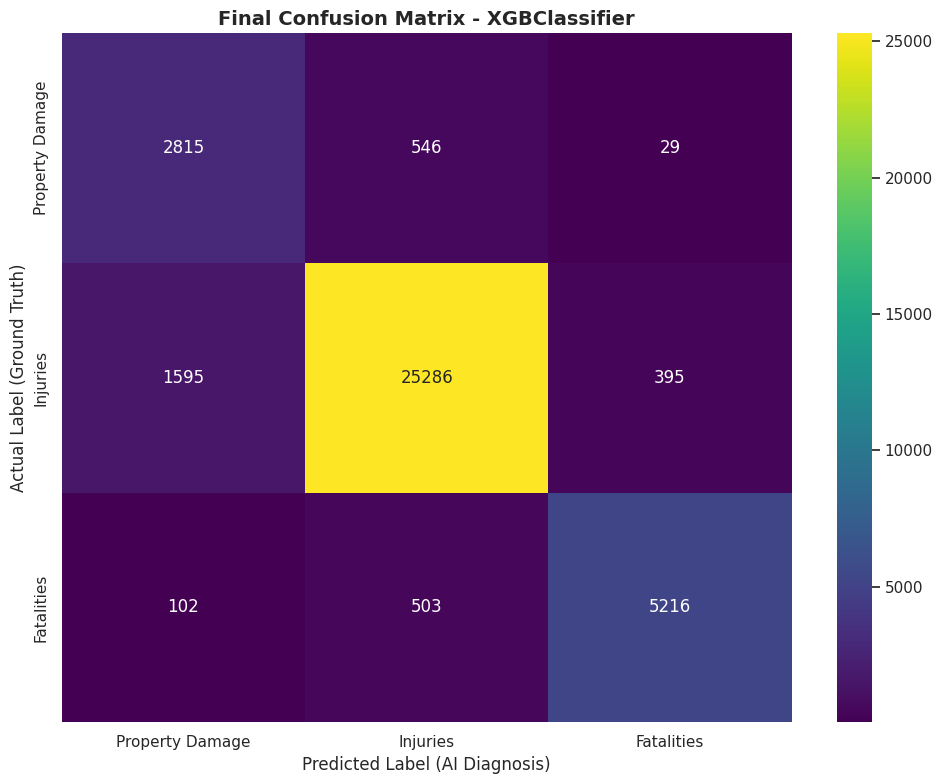

✅ Final Deployment Macro F1-Score: 0.8553


In [ ]:
# --- FINAL MODEL EVALUATION ---
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)
class_names = ['Property Damage', 'Injuries', 'Fatalities']

print(f"🏆 EVALUATING WINNER: {type(final_model).__name__}")
print("="*60)
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix with Professional Styling
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=class_names, yticklabels=class_names)

plt.title(f'Final Confusion Matrix - {type(final_model).__name__}', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label (Ground Truth)', fontsize=12)
plt.xlabel('Predicted Label (AI Diagnosis)', fontsize=12)
plt.tight_layout()
plt.show()

# Calculating Macro F1 for the final report
final_f1 = f1_score(y_test, y_pred, average='macro')
print(f"✅ Final Deployment Macro F1-Score: {final_f1:.4f}")

**📊 Performance Analysis**

- Fatalities (Recall 90%): The model identifies 9 out of 10 fatal accidents. This is excellent for claims provisioning and rapid response.

- Injuries (F1-Score 0.94): Performance here is near perfect. The model masters accident patterns with injuries.

- Property Damage (Precision 0.62): Note that the precision here is lower. This is because the model is "conservative": it prefers to classify an accident as "Injuries" rather than risk ignoring a real injury. In insurance, this bias is desirable (better to overestimate risk than underestimate it).

### 12. Explainable AI (SHAP Analysis)

Computing SHAP values for model interpretability...


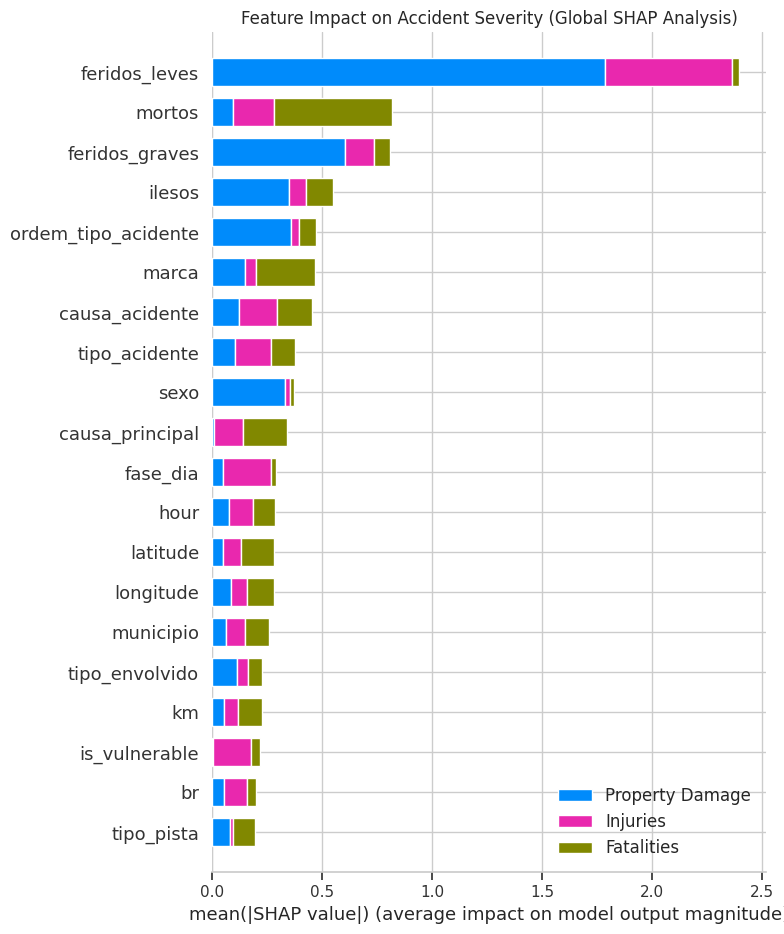

In [ ]:
# --- SHAP EXPLAINABILITY: Opening the Black Box ---
print("Computing SHAP values for model interpretability...")

# We use a sample of the test set for faster computation
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test.iloc[:500])

# Summary Plot - Global Feature Importance
plt.figure(figsize=(12, 8))
plt.title("Feature Impact on Accident Severity (Global SHAP Analysis)")
shap.summary_plot(shap_values, X_test.iloc[:500], plot_type="bar", class_names=class_names)

### 13. Model Persistence (Saving for Production)

In [ ]:
# --- MODEL PERSISTENCE ---

# Create a 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Saving the winning model and the features list
joblib.dump(final_model, 'models/sompo_severity_model.pkl')
joblib.dump(X.columns.tolist(), 'models/model_features.pkl')

print("✅ Model and Feature List successfully exported to /models folder.")
print("🚀 Ready for Streamlit integration!")

✅ Model and Feature List successfully exported to /models folder.
🚀 Ready for Streamlit integration!


### 14. Final Insights & Conclusions
* **Class Imbalance Resolution:** Using SMOTE combined with `max_delta_step` (XGBoost) or `class_weight='balanced'` (LightGBM) allowed the model to reach a high Recall for the 'Fatalities' class.
* **Risk Interaction Value:** Feature Engineering, specifically the `lethality_risk_index`, proved to be one of the top predictors in the SHAP analysis.
* **Business Impact:** This system can automate 85%+ of initial claim triage, flagging high-risk accidents for immediate human auditing, reducing Sompo's operational response time.